In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
train_df = pd.read_csv('/content/bean-leaf-lesions-classification/train.csv')
val_df = pd.read_csv('/content/bean-leaf-lesions-classification/val.csv')

train_df['image:FILE'] = "/content/bean-leaf-lesions-classification/" + train_df['image:FILE']
val_df['image:FILE'] = "/content/bean-leaf-lesions-classification/" + val_df['image:FILE']
train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/trai...,0
1,/content/bean-leaf-lesions-classification/trai...,0
2,/content/bean-leaf-lesions-classification/trai...,0
3,/content/bean-leaf-lesions-classification/trai...,0
4,/content/bean-leaf-lesions-classification/trai...,0


In [ ]:
train_df['category'].unique()
print(train_df.shape)
print(val_df.shape)
print(train_df['category'].value_counts())

(1034, 2)
(133, 2)
category
2    348
1    345
0    341
Name: count, dtype: int64


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe['category']).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx,0]
    label = self.labels[idx]
    image = Image.open(img_path)

    if self.transform:
      image = (self.transform(image)/255.0).to(device)

      return image, label

In [ ]:
train_dataset = CustomImageDataset(dataframe = train_df, transform = transform)
val_dataset = CustomImageDataset(val_df, transform)

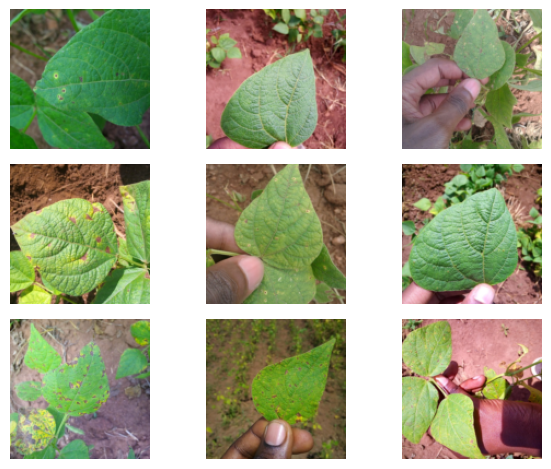

In [ ]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = train_dataset[np.random.randint(0,train_dataset.__len__())][0].cpu()
    axarr[row, col].imshow((image*255.0).squeeze().permute(1,2,0))
    axarr[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 15

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
googlenet_model = models.googlenet(weights = 'DEFAULT')

In [ ]:
for params in googlenet_model.parameters():
  params.requires_grad = True

In [ ]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [ ]:
num_classes = len(train_df['category'].unique())
print(num_classes)

3


In [ ]:
googlenet_model.fc = torch.nn.Linear(in_features = 1024, out_features = num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [ ]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr = LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for inputs, labels in train_dataloader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fun(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    total_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += total_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100, 4))

  print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100, 4)} %')

Epoch 1/15, Train Loss: 0.2525, Train Accuracy: 52.9014 %
Epoch 2/15, Train Loss: 0.2378, Train Accuracy: 54.0619 %
Epoch 3/15, Train Loss: 0.208, Train Accuracy: 64.2166 %
Epoch 4/15, Train Loss: 0.1971, Train Accuracy: 67.9884 %
Epoch 5/15, Train Loss: 0.1784, Train Accuracy: 71.0832 %
Epoch 6/15, Train Loss: 0.1628, Train Accuracy: 75.7253 %
Epoch 7/15, Train Loss: 0.1612, Train Accuracy: 74.8549 %
Epoch 8/15, Train Loss: 0.1514, Train Accuracy: 77.3694 %
Epoch 9/15, Train Loss: 0.1521, Train Accuracy: 77.0793 %
Epoch 10/15, Train Loss: 0.1363, Train Accuracy: 79.6905 %
Epoch 11/15, Train Loss: 0.134, Train Accuracy: 81.1412 %
Epoch 12/15, Train Loss: 0.1236, Train Accuracy: 81.4313 %
Epoch 13/15, Train Loss: 0.1122, Train Accuracy: 83.2689 %
Epoch 14/15, Train Loss: 0.1091, Train Accuracy: 83.559 %
Epoch 15/15, Train Loss: 0.094, Train Accuracy: 86.2669 %


In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for input, labels in val_dataloader:
    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc


In [ ]:
print(round(total_acc_test/val_dataset.__len__()*100, 2))

87.22


# Transfer Learning

In [ ]:
googlenet_model = models.googlenet(weights = 'DEFAULT')

for params in googlenet_model.parameters():
  params.requires_grad = False

googlenet_model.fc = torch.nn.Linear(in_features = 1024, out_features = num_classes)
googlenet_model.fc.requires_grad = True
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr = LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for inputs, labels in train_dataloader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fun(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    total_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += total_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100, 4))

  print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100, 4)} %')

Epoch 1/15, Train Loss: 0.2622, Train Accuracy: 50.0967 %
Epoch 2/15, Train Loss: 0.2456, Train Accuracy: 53.5783 %
Epoch 3/15, Train Loss: 0.2292, Train Accuracy: 59.0909 %
Epoch 4/15, Train Loss: 0.2264, Train Accuracy: 61.0251 %
Epoch 5/15, Train Loss: 0.2222, Train Accuracy: 62.766 %
Epoch 6/15, Train Loss: 0.2149, Train Accuracy: 62.9594 %
Epoch 7/15, Train Loss: 0.2297, Train Accuracy: 61.2186 %
Epoch 8/15, Train Loss: 0.2233, Train Accuracy: 61.7021 %
Epoch 9/15, Train Loss: 0.2188, Train Accuracy: 61.3153 %
Epoch 10/15, Train Loss: 0.2175, Train Accuracy: 62.4758 %
Epoch 11/15, Train Loss: 0.2184, Train Accuracy: 60.6383 %
Epoch 12/15, Train Loss: 0.2246, Train Accuracy: 60.058 %
Epoch 13/15, Train Loss: 0.2186, Train Accuracy: 62.6692 %
Epoch 14/15, Train Loss: 0.2204, Train Accuracy: 59.7679 %
Epoch 15/15, Train Loss: 0.2162, Train Accuracy: 62.5725 %


In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for input, labels in val_dataloader:
    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

In [ ]:
print(round(total_acc_test/val_dataset.__len__()*100, 2))

66.17
